In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('nobel_prize_winners - nobel_prize_winners.csv',sep = ',')

In [3]:
data.duplicated().sum()


np.int64(0)

In [4]:
(data['birth_country'] != data['birth_countryNow']).sum()

np.int64(138)

In [5]:
data = data.drop(columns=['categoryTopMotivation', 'penName']) # these columns are not salvagable and were not used in the analysis
data.isnull().sum()




awardYear                       0
category                        0
categoryFullName                0
sortOrder                       0
portion                         0
prizeAmount                     0
prizeAmountAdjusted             0
dateAwarded                   417
prizeStatus                     0
motivation                      0
award_link                      0
id                              0
name                            0
knownName                      27
givenName                      27
familyName                     29
fullName                       27
gender                         27
laureate_link                   0
birth_date                     27
birth_city                     28
birth_cityNow                  28
birth_continent                27
birth_country                  27
birth_countryNow               27
birth_locationString           27
death_date                    320
death_city                    339
death_cityNow                 339
death_continen

<Axes: xlabel='ind_or_org'>

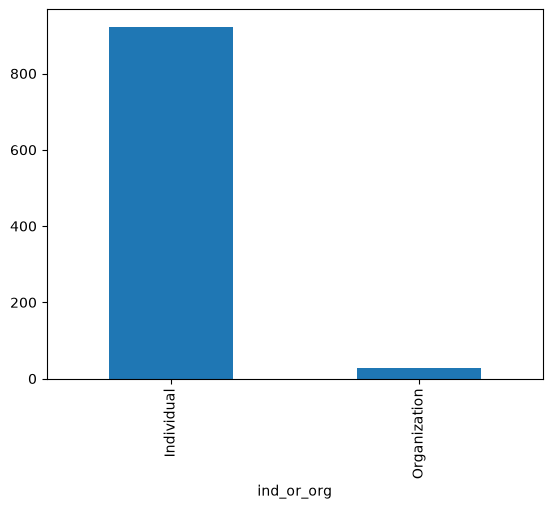

In [6]:
# One of the things that i noticed is that gender , birthdate , birthcontient and some other columns have exactly 27 null values. I will investigate this further to see if there is a pattern or if it is just random missing data.
data[data['ind_or_org'] == 'Organization']['gender'].isna().sum()
data['ind_or_org'].value_counts().plot(kind='bar')

# turns out that all of the null values in these columns are from organizations. This makes sense because organizations do not have a gender 


<Axes: xlabel='gender'>

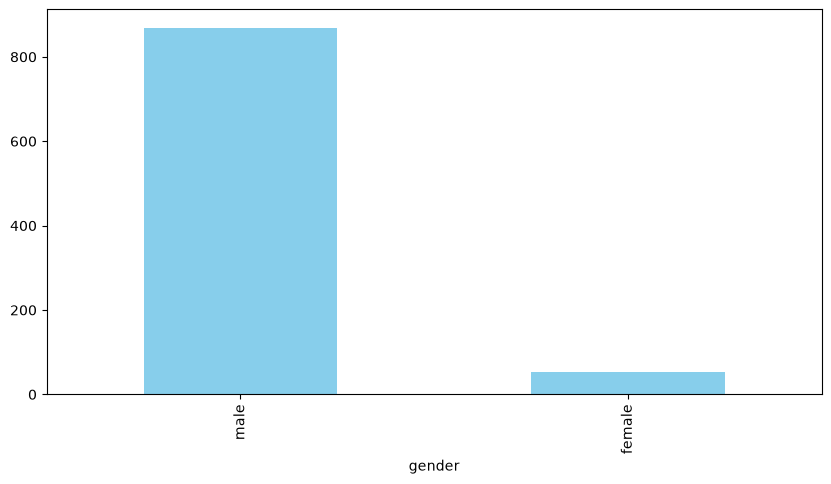

In [7]:
# diffeerent gender counts and a bar plot to visualize the
data['gender'].value_counts()
data['gender'].value_counts().plot(kind='bar', figsize=(10, 5), color='skyblue')

<Axes: xlabel='age'>

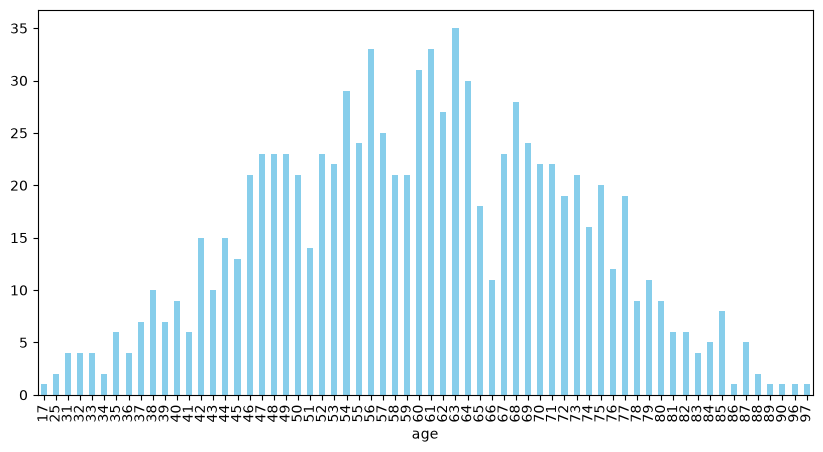

In [8]:
# I created a new feature called age by merding the birth_daate and  awardYear columns.
birth_year = pd.to_numeric(data['birth_date'].astype('string').str[:4], errors='coerce') # exeptions are handled by converting the birth_date to string and then extracting the first 4 characters (the year) and converting it to numeric. Any errors in conversion will be set to NaN.

data['age'] = (data['awardYear'] - birth_year).astype('Int64') # casting the age to Int64 to handle NaN values. This will give us the age of the laureate at the time of receiving the award.

data[['name', 'birth_date', 'awardYear', 'age']].head()
data['age'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5), color='skyblue') # bar plot to visualize the age distribution of the laureates



In [9]:
grouped_age = data.groupby('age').size().reset_index(name='count') # group the data by age and count the number of laureates for each age
grouped_age

mean_age = data.groupby('gender')['age'].mean().astype(int) # mean age of laureates by gender
mean_age



gender
female    57
male      59
Name: age, dtype: int64

In [10]:
Gap_years = data.groupby('awardYear').size().reset_index(name='count').set_index('awardYear')
Gap_years = Gap_years.reindex(range(1901, 2020), fill_value=0)
gap_years = Gap_years.reset_index().rename(columns={'index': 'year', 0: 'count'})
gap_years

,awardYear,count
0,1901,6
1,1902,7
2,1903,7
3,1904,6
4,1905,5
...,...,...
114,2015,11
115,2016,11
116,2017,12
117,2018,13


gender,female,male
category,,
Chemistry,0.027174,0.972826
Economic Sciences,0.023810,0.976190
Literature,0.129310,0.870690
Peace,0.158879,0.841121
Physics,0.014085,0.985915
Physiology or Medicine,0.054795,0.945205


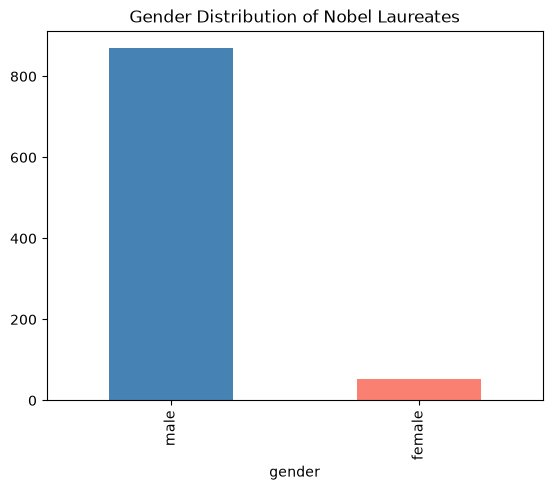

In [11]:
# the next few blocks works cross sectionally of gender and the rest of the dataset
data['gender'].value_counts()
data['gender'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], title='Gender Distribution of Nobel Laureates')
pd.crosstab(data['category'], data['gender'], normalize='index') # cross tabulation to see the distribution of gender across different categories of Nobel
#.crosstab is a new function that I learned about in this assignment. It is a very useful function for creating contingency tables and can be used to analyze the relationship between two categorical variables. it returns a DataFrame that shows the frequency distribution of the variables. The normalize='index' parameter normalizes the values by the row totals, giving us the proportion of each gender within each category.

In [12]:
max_age =print(data.age.max()) # maximum age of laureates
min_age = print(data.age.min()) # minimum age of laureates

gender_age_stats = data.groupby('gender')['age'].agg(['mean', 'max', 'min']).astype(int) # mean, max, and min age of laureates by gender
gender_age_stats



97
17


,mean,max,min
gender,,,
female,57,88,17
male,59,97,25


In [ ]:
data['decade'] = (data['awardYear'] // 10) * 10

pd.crosstab(
    data['decade'],
    data['gender'],
    normalize='index'
).mul(100).round(2)
pd.crosstab(data['decade'], data['gender'], normalize='index')['female'].plot(kind='line', marker='o', title='Female Share of Nobel Laureates by Decade')


KeyError: 'decade'

<Axes: title={'center': 'Age at Time of Award'}, ylabel='Frequency'>

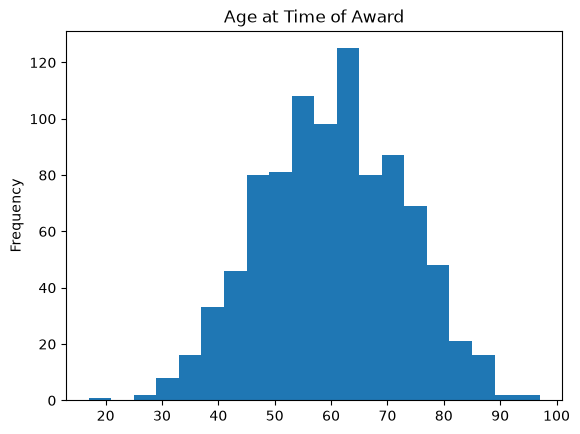

In [ ]:
data['age'].plot(kind='hist', bins=20, title='Age at Time of Award')

<Axes: title={'center': 'age'}, xlabel='category'>

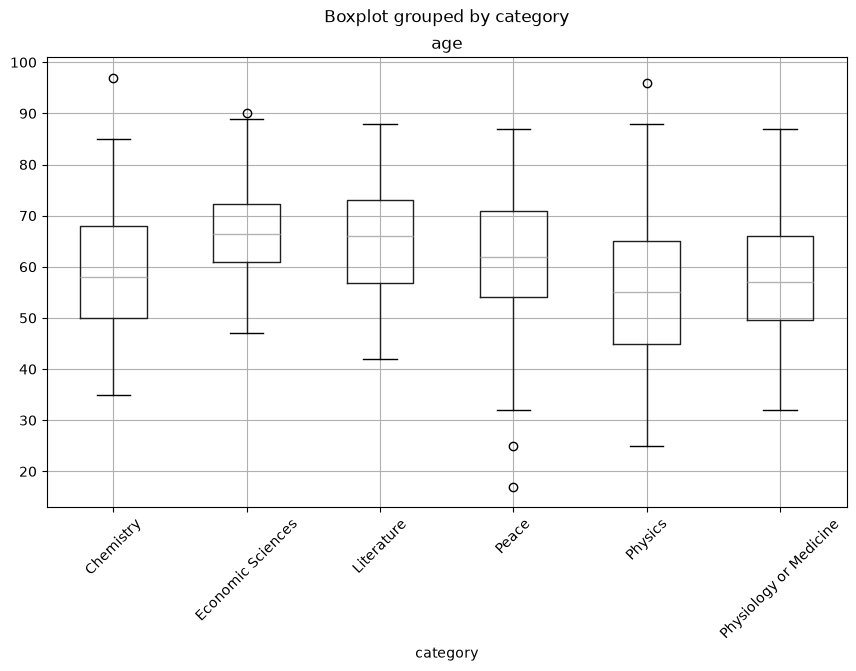

In [ ]:
# A visualization of the age distribution of laureates by category using a boxplot. This will help us understand the spread and central tendency of ages within each category.
data.boxplot(column='age', by='category', figsize=(10,6), rot=45)


<Axes: title={'center': 'Average Age at Award by Decade'}, xlabel='decade'>

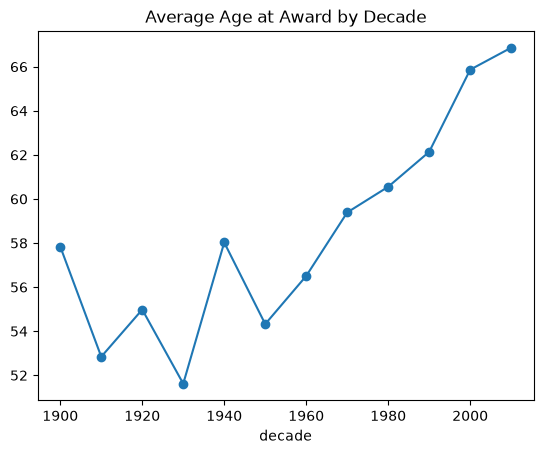

In [ ]:
data.groupby('decade')['age'].mean().plot(kind='line', marker='o', title='Average Age at Award by Decade')

In [ ]:
"""
My insights so far are that the average age of Nobel laureates has been increasing over the decades, with a notable increase in the 21st century. Additionally, there is
    a gender disparity in the ages of laureates, with female laureates generally being younger than their male counterparts at the time of receiving the award. 
    The distribution of ages also varies across different categories, with some categories having a wider age range than others. 
    The data also shows that there are certain years, particularly during WWI and WWII, where the number of awards given was significantly lower, 
    which could be attributed to the global events of those times.

    Also That winner based on gender tend to favour males Over females, with males consistently making up a larger proportion
     and that the proportion of female laureates has been gradually increasing

     New : I created a new feature called age by merging the birth_date and awardYear columns. This allows us to analyze the age distribution of laureates at the time of receiving the award.
     that helped cross tabulate the age factor for individuals across all categories and gender. I also created visualizations to better understand the distribution of ages and the relationship
     and trends over time. The analysis revealed that the average age of laureates has been increasing over the decades, with a notable increase in the 21st century. Additionally, there is a gender disparity 

     As an insight the creation of the feature 'age' allowed for a more nuanced analysis of the data, revealing trends and disparities that were not immediately apparent from the raw data alone


"""

"\nthis code is disabled for now\ndata['x'].plot()\n"

<Axes: title={'center': 'Top 10 Countries by Nobel Laureates'}, ylabel='birth_countryNow'>

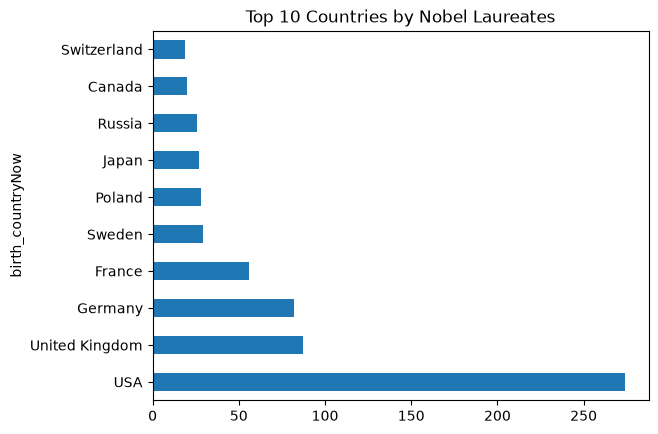

In [ ]:
# the next few blocks are gonna be foucused on geographical distribution of the laureates and there inights across differrent feats
data['birth_countryNow'].value_counts().head(15)

data['birth_countryNow'].value_counts().head(10).plot(kind='barh', title='Top 10 Countries by Nobel Laureates')

portion,1,1/2,1/3,1/4
decade,,,,
1900,59.6,36.8,0.0,3.5
1910,80.0,20.0,0.0,0.0
1920,63.0,37.0,0.0,0.0
1930,58.9,35.7,5.4,0.0
1940,55.8,27.9,7.0,9.3
1950,41.7,34.7,20.8,2.8
1960,36.7,29.1,26.6,7.6
1970,26.0,40.4,26.0,7.7
1980,37.1,27.8,24.7,10.3


In [ ]:
top_countries = data['birth_countryNow'].value_counts().head(5).index
pd.crosstab(data[data['birth_countryNow'].isin(top_countries)]['birth_countryNow'], data['category'])
age_by_country = data.groupby('birth_countryNow')['age'].mean().sort_values(ascending=False).head(10)
age_by_country.astype(int)

birth_countryNow
South Korea               79
Bulgaria                  76
Portugal                  75
Peru                      74
Guadeloupe Island         73
Madagascar                72
Iran                      72
North Macedonia           69
Belarus                   69
Bosnia and Herzegovina    69
Name: age, dtype: int64

<Axes: title={'center': 'Country Share of Nobel Laureates by Decade'}, xlabel='decade'>

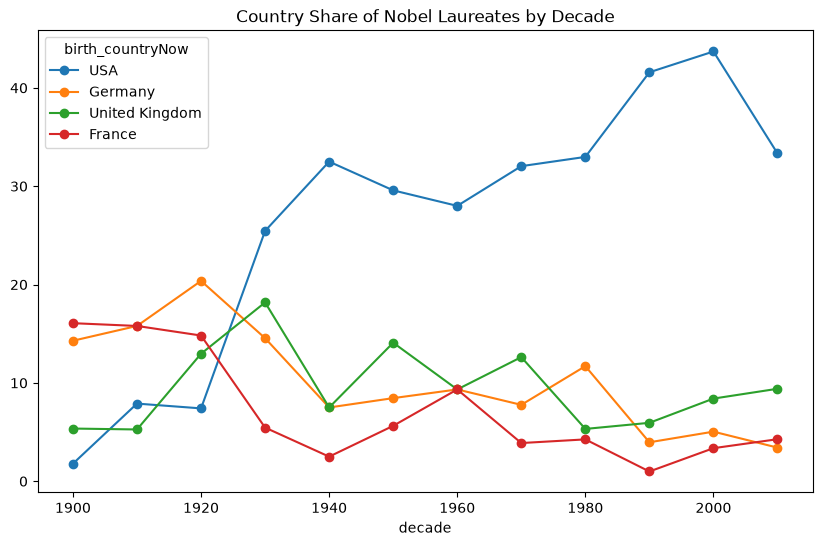

In [ ]:
# this block is to visualize the share of Nobel laureates by country over the decades. It focuses on the top 4 countries with the highest number of laureates and shows how their share has changed over time.
top4 = ['USA', 'Germany', 'United Kingdom', 'France']
pd.crosstab(data['decade'], data['birth_countryNow'], normalize='index')[top4] * 100
pd.crosstab(data['decade'], data['birth_countryNow'], normalize='index')[top4].mul(100).plot(kind='line', marker='o', figsize=(10,6), title='Country Share of Nobel Laureates by Decade')

In [ ]:
"""
I don't know if this counts as an insight but I actaully got curious , u see at the begingThe timing of that crossover right around the 1930s-40s lines up suspiciously well with WWII and, 
just before it, the Nazi-era persecution that drove many scientists (a lot of them Jewish researchers) out of Germany and into US universities. 
That's a plausible explanation for the handoff, not something the data proves outright ,it's a hypothesis based on historical timing, 
but it does seem to fit the narrative of what was happening in the world at that time.

"""

In [ ]:
pd.crosstab(data['decade'], data['category'], normalize='index').mul(100).plot(kind='area', figsize=(12,6), title='Category Share of Nobel Prizes by Decade')

KeyError: 'decade'

In [ ]:
#question 1 :
 # id.max() ---> returns the label of the maximum value in the series
 # value_counts() ---> returns a series containing counts of unique values 


top_gender = data['gender'].value_counts().idxmax() # get the gender with the highest count
top_country = data['birth_country'].value_counts().idxmax() # get the country with the highest count

top_gender, top_country


('male', 'USA')

In [ ]:
# question 2 :
data['decade'] = (data['awardYear'] // 10) * 10 # create a new column for the decade of the award year

usa_ratio_by_decade = data.groupby('decade').apply(
    lambda g: (g['birth_country'] == 'USA').sum() / len(g) # calculate the ratio of USA winners in each decade
)
max_decade_usa = int(usa_ratio_by_decade.idxmax())

max_decade_usa

2000

In [ ]:
data['is_female'] = data['gender'] == 'female'  # create a new column to indicate if the winner is female

total_per_group = data.groupby(['decade', 'category'])['is_female'].count()
female_per_group = data.groupby(['decade', 'category'])['is_female'].sum()

female_prop = female_per_group / total_per_group
best_decade, best_category = female_prop.idxmax()
max_female_dict = {int(best_decade): best_category}

max_female_dict

{2010: 'Peace'}

In [ ]:
# question 4 : 

females = data[data['gender'] == 'female']       # Select only female winners from the dataset     
first_woman = females.loc[females['awardYear'].idxmin()] # Get the row corresponding to the first female (by finding the index of the minimum award year)

first_woman_name = first_woman['name']
first_woman_category = first_woman['category']

first_woman_name, first_woman_category

('Marie Curie', 'Physics')

In [ ]:
# question 5:  

wins_per_id = data.groupby('id')['awardYear'].count()
repeat_ids = wins_per_id[wins_per_id > 1].index

repeat_list = data[data['id'].isin(repeat_ids)]['name'].drop_duplicates().tolist()

repeat_list

['Frederick Sanger',
 'International Committee of the Red Cross',
 'John Bardeen',
 'Linus Pauling',
 'Marie Curie',
 'Office of the United Nations High Commissioner for Refugees']